# QISKIT: Carregamento

In [1]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wh

'2.4.1'

In [2]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

In [3]:
def qiskit_sampler(circuito_com_medidas, shots = None, backend = None):
    '''
    Método para executar o Sampler
    >>> O Sampler realiza medidas em circuitos quânticos e retorna a contagem de qubits.
        A partir dos resultados do Sampler, podemos estimar as probabilidade de cada resultado.

    Input:
        circuito : circuito quântico que prepara um estado de qubits
        backend  : backend para rodar o Sampler

    Saída:
        resultado do Sampler

    Observação: os resultados do Sampler são rotulados pelo nomes dos registros clássicos.
                Para um circuito com medidas definidas por 'measure_all', o rótulo é 'meas'.
                Para circuitos com medidas definidas de início sem denominação explícita,
                os rótulos são 'c', 'c1', 'c2', etc.

    Tutorial do Sampler: https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/sampler-v2
    '''

    # Importação de métodos e backend

    from qiskit_ibm_runtime import SamplerV2 as Sampler

    if backend is None:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane
        backend = FakeBrisbane()
    else:
        backend = backend

    from qiskit.transpiler import generate_preset_pass_manager
    pm = generate_preset_pass_manager(optimization_level=2, backend = backend)

    # Transpilação

    isa_circuitos = pm.run(circuito_com_medidas)
    #display(isa_circuitos.draw('mpl'))

    if shots is None:
        shots = 2**10
    else:
        shots = shots

    sampler = Sampler(backend)
    job = sampler.run([(isa_circuitos, )], shots = shots)
    result = job.result()

    # Identificação do nome do primeiro registro clássico
    classical_register_name = isa_circuitos.cregs[0].name
    counts = result[0].data[classical_register_name].get_counts()

    return counts, result

# Estados de Hipergrafos

*   **Referência**: M. Rossi, M. Huber, D. Bruß, C. Macchiavello: <i>Quantum hypergraph states</i>. New Journal of Physics, Volume 15, 113022 (2013). DOI:10.1088/1367-2630/15/11/113022. URL: [https://iopscience.iop.org/article/10.1088/1367-2630/15/11/113022](https://iopscience.iop.org/article/10.1088/1367-2630/15/11/113022).


***

**Transformação hipergráfica**

Função zeta
$$
\zeta: \left\{0,1\right\} \rightarrow\left\{0,1\right\},\ \zeta(x) = 1 - x \therefore \left\lbrace %
\begin{array}{l}
\zeta(0) = \bar{0} := 1,\\
\zeta(1) = \bar{1} := 0.
\end{array}
 \right.
$$

Sejam $g = (V,E)$ um hipergrafo de cardinalidade $n \in \mathbb{N}$ com vértices $V$ e hiper-arestas $E$,

$$
V = \left\{0, 1, \dots, n-1 \right\},\ E \subseteq P(\left\{0, 1, \dots, n-1\right\}),
$$

e $f$ uma sequência booleana
$$
f = (f_0, f_1, \dots, f_{2^n-1}) \in \left\{0,1\right\}^{2^n}.
$$
A ação de $g$ em $f$ é definida por:
$$
g(f) \equiv f^g \in \left\{0,1\right\}^{2^n},
$$
onde:
*   $E = \left\{\left\{i\right\}\right\} \subset P(V)$ ($1$-hiperaresta)  $\therefore$
$$
g(f) \equiv f^g = (f^\left\{i\right\}_0, f^\left\{i\right\}_1, \dots, f^\left\{i\right\}_{2^n-1}),\ f^\left\{i\right\}_k:= \left\{
    \begin{array}{ll}
    \bar{f_\ell}, & \text{se}\ \mathrm{bin}(\ell)_i = 1,\\
    f_\ell, & \text{se}\ \mathrm{bin}(\ell)_i = 0.
    \end{array}
    \right.
$$
*   $E = \left\{\left\{i_0, \dots, i_{k-1}\right\}\right\}\subset P(V)$ ($k$-hiperaresta) $\therefore$
$$
g(f) \equiv f^g = (f^\left\{i_0, \dots, i_{k-1}\right\}_0, f^\left\{i_0, \dots, i_{k-1}\right\}_1, \dots, f^\left\{i_0, \dots, i_{k-1}\right\}_{2^n-1}),\ f^\left\{i_0, \dots, i_{k-1}\right\}_k:= \left\{
    \begin{array}{ll}
    \bar{f_\ell}, & \text{se}\ \mathrm{bin}(\ell)_{i_0} = \dots = \mathrm{bin}(\ell)_{i_{n-1}} = 1,\\
    f_\ell, & \lnot (\mathrm{bin}(\ell)_{i_0} = \dots = \mathrm{bin}(\ell)_{i_{n-1}} = 1).
    \end{array}
    \right.
$$
*   $E = \left\{ e_0, e_1, \dots , e_{m-1} \right\} \subseteq P(V)$ $\therefore$
$$
g(f) \equiv f^g = (\dots((f^{e_0})^{e_1}) \dots )^{e_{m-1}}.
$$

In [4]:
def HGrafo(f, E):
    '''
    Método que realiza a transformação hipergráfica de uma sequência booleana.

    Entradas
        n (int) : número de vértices do hipergrafo (n >= 1)
        f (list): lista booleana de comprimento 2**n, com entradas 0 ou 1.
        E (list): arestas do hipergrafo (lista de subconjuntos de Z[0,n-1])


    Saída
        g(f): transformação hipergráfica de f por g = (V,E), V = {0, 1, ..., n-1}.

    Método auxiliar:
        numpy

    Observação:
        Nenhuma hiperaresta muda o valor de f[0]. Quanticamente, a mudança do
        valor de f[0] pode ser realizada por uma fase global.
    '''

    # Testes de consistência nas entradas

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None

    for edge in E:
        for vertex in edge:
            if vertex < 0 or vertex >= n:
                return print('Erro nas entradas n e E!')


    fg = f.copy()

    # Ação de k-hiperaresta

    def k_hiperaresta(edge, f):

        fg = f.copy()

        if [0] in edge:
            for k in range(2**n):
                fg[k] = 1 - fg[k]

        for k in range(2**n):
            digitos = [list(bin(k)[2:].zfill(n))[i] for i in range(n)]
            digitos.reverse()
            condicao = True
            for vertex in edge:
                if digitos[vertex] != '1':
                    condicao = False
                    break
            if condicao == True:
                fg[k] = 1 - fg[k]

        return fg

    # Ação do hipergrafo

    for edge in E:
        fg = k_hiperaresta(edge, fg)

    return fg

In [5]:
# EXEMPLO

## Criar o estado (0,0,1,0,1,0,1,0) a partir de (0,0,0,0,0,0,0,0)


f = [0,0,0,0,0,0,0,0]
print(f"f: {f}")
E = [[1],[2],[0,1],[0,2],[1,2],[0,1,2]]
print(f"E: {E}")
fg = HGrafo(f, E)
print(f"fg: {fg}")

print("ANULAR")

h = HGrafo(fg,E)
print(f"h: {h}")


f: [0, 0, 0, 0, 0, 0, 0, 0]
E: [[1], [2], [0, 1], [0, 2], [1, 2], [0, 1, 2]]
fg: [0, 0, 1, 0, 1, 0, 1, 0]
ANULAR
h: [0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
def HGraforew(f):
    '''
    Método que constrói o hipergrafo que cria uma dada sequência booleana a partir
    da sequência booleana nula.

    Entradas
        n (int) : número de vértices do hipergrafo (n >= 1)
        f (list): lista booleana de comprimento 2**n, com entradas 0 ou 1.


    Saída
        E (list): lista de arestas (subconjuntos de V = {0, 1, ..., n-1}).
    '''

    # Testes de consistência nas entradas

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None

    # Construção da lista

    if n <= 0: # Caso n <= 0
        print("Erro na entrada n!")
        return None

    elif n == 1: # Caso n = 1
        if f[1] == 0:
            return []
        elif f[1] == 1:
            return [[0]]
        else:
            print("Erro na entrada f!")
            return None

    else: # Caso n > 1
        if f[2**(n-1)] == 0: # Ação no qubit 'n-1', correspondente ao zerésimo termo da segunda metade de f
            E = []
            fg = f.copy()
        elif f[2**(n-1)] == 1:
            E = [[n-1]]
            fg = HGrafo(f,E)

        f0 = fg[0:2**(n-1)] # Divisão da lista em duas partes
        f1 = fg[2**(n-1):]

        # Recursividade

        E0 = HGraforew(f0)

        if E0 is None: # Propaga erro
            return None

        f11 = HGrafo(f1,E0)
        if f11 is None: # Propaga erro
            return None

        E1 = HGraforew(f11)
        if E1 is None: # Propaga erro
            return None

        for edge in E1:
            edge.append(n-1)

        E = E + E0 + E1
        return E

In [7]:
# EXEMPLO

f = [0,1,0,0]
print(f"f: {f}. len(f): {len(f)}")

E = HGraforew(f)
#E = [[0,1,2]]
print(f"E: {E}")

fg = HGrafo(f, E)
print(f"fg: {fg}")

f: [0, 1, 0, 0]. len(f): 4
E: [[0], [0, 1]]
fg: [0, 0, 0, 0]


In [8]:
# EXEMPLO

f = [0,0,0,1]
print(f"f: {f}. len(f): {len(f)}")

E = HGraforew(f)
#E = [[0,1,2]]
print(f"E: {E}")

fg = HGrafo(f, E)
print(f"fg: {fg}")

f: [0, 0, 0, 1]. len(f): 4
E: [[0, 1]]
fg: [0, 0, 0, 0]


In [9]:
def Rew(f):
    '''
    Método que constrói o circuito que prepara o estado REW associado à sequência booleana

    Entradas:
        n (int) : número de vértices do hipergrafo (n >= 1)
        f (list): lista booleana de comprimento 2**n, com entradas 0 ou 1.


    Saída:
        QuantumCircuit: circuito quântico que prepara o estado REW associadao a 'f'.

    Métodos auxiliares:
        HGraforew(n,f): constrói o hipergrafo que cria uma dada sequência booleana a partir
        da sequência booleana nula.
        qiskit.circuit.library.standard_gates.ZGate
    '''

    # Testes de consistência nas entradas

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None

    # Criação do hipergrafo que gera f

    E = HGraforew(f)
    if E is None: # Propaga erro
        return None

    # Criação do circuito

    qc = QuantumCircuit(n)
    for k in range(n):
        qc.h(k)

    if E == []:
        return qc

    else:

        from qiskit.circuit.library.standard_gates import ZGate

        for edge in E:
            if len(edge) == 1:
                qc.z(edge[0])
            else:
                cz_gate_edge = ZGate().control(len(edge)-1)
                qc.append(cz_gate_edge, edge)
        return qc

f: [0, 0, 1, 0, 1, 0, 1, 0]. len(f): 8
E: [[2], [1], [0, 1], [1, 2], [0, 2], [0, 1, 2]]


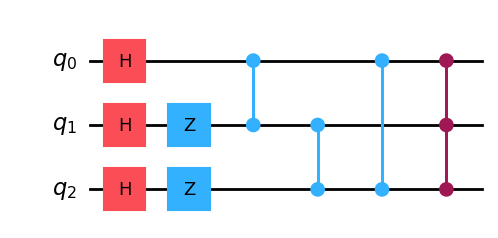

<IPython.core.display.Latex object>

In [10]:
# EXEMPLO

f = [0,0,1,0,1,0,1,0]
print(f"f: {f}. len(f): {len(f)}")

E = HGraforew(f)
print(f"E: {E}")

qc = Rew(f)

display(qc.draw('mpl'))

# Print do estado preparado

from qiskit.quantum_info import Statevector

estado = Statevector.from_instruction(qc)
estado.draw('latex')

In [11]:
from qiskit.quantum_info import Statevector
from qiskit import transpile # Ensure transpile is imported here, even if already global

def Qprod(f,h, shots = None, aer_flag = None, backend = None):
    '''
    Método que realiza o produto vetorial de duas sequências booleanas.

    OBSERVAÇÃO: só funciona se as primeiras entradas de f e h forem iguais a 0!!!

    Entradas:
        f (list)...: lista booleana de comprimento 2**n, com entradas 0 ou 1.
        h (list)...: lista booleana de comprimento 2**n, com entradas 0 ou 1.
        shots (int): número de experimentos.
        aer_flag (bool): variável que define o tipo de experimentos:
                         simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend): backend para realização dos experimentos quânticos.

    Saída:
        qprod (float): produto vetorial de f e h.

    Métodos auxiliares:
        HGraforew(n,f): método que constrói o hipergrafo que cria uma dada
            sequência booleana a partir da sequência booleana nula

        HGrafo(n, f, E): método que realiza a transformação hipergráfica de uma
            sequência booleana.

        HGraforew(n,f): método que constrói o hipergrafo que cria uma dada
            sequência booleana a partir da sequência booleana nula.

        Rew(n,f): método que constrói o circuito que prepara o estado REW
    '''

    # Teste de consistência dos dados de entrada

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None
    elif len(f) != len(h):
        print('Erro na entrada h: seu comprimento deve ser igual ao de f!')
        return None

    # Criação do circuito que prepara U_f e V_h

    qc = QuantumCircuit(n+1,1)

    qcf = Rew(f)
    if qcf is None: # Propaga erro
        return None

    qc.compose(qcf, range(n), inplace = True)

    qc.barrier()

    #display(qc.draw('mpl'))
    #statevector = Statevector.from_instruction(qc)
    #print("Rew(f)")
    #display(statevector.draw('latex'))

    qch = Rew(h)
    if qch is None: # Propaga erro
        return None
    #display(qch.draw('mpl'))
    #statevector = Statevector.from_instruction(qch)
    #display(statevector.draw('latex'))

    qch_dagger = qch.inverse()

    qc.compose(qch_dagger, range(n), inplace = True)

    qc.barrier()

    for k in range(n):
        qc.x(k)

    from qiskit.circuit.library.standard_gates import XGate

    cz_gate = XGate().control(n)

    qc.append(cz_gate, range(n+1))

    qc_aux = qc.copy()

    qc.measure(n,[0])

    # Print circuito e vetor-estado produzidos

    #display(qc.draw('mpl'))
    #statevector = Statevector.from_instruction(qc_aux)
    #display(statevector.draw('latex'))

    # Medida

    if shots is None:
        shots = 2**10

    if aer_flag is True:
        from qiskit_aer import AerSimulator

        simulator = AerSimulator()

        # Transpile the circuit for the simulator's basis gates
        transpiled_qc = transpile(qc, simulator)

        job = simulator.run(transpiled_qc, shots= shots)
        result = job.result()

        counts = result.get_counts(qc)

        prod = (2**n)*np.sqrt(counts.get('1', 0)/shots)

        #print("\nTotal counts:", counts)

    elif backend is None:
        pass

    return prod, qc_aux

In [12]:
# EXEMPLO 1

n = 1

f = [0,0]
print(f"f: {f}. len(f): {len(f)}")

h = [0,1] # [1,1,0,1,0,1,0,1] #[1,1,1,0,1,0,0,0] #f.copy()
print(f"h: {h}. len(h): {len(h)}")

prod = 0
for k in range(2**n):
    prod += ((-1)**f[k])*((-1)**h[k])
print(f"f*h: {prod}")

shots = 2**10
qprod = Qprod(f,h, shots = shots, aer_flag = True)
print(f"qprod: {qprod}")
print(f"Produto interno: {qprod[0]}")

f: [0, 0]. len(f): 2
h: [0, 1]. len(h): 2
f*h: 0
qprod: (np.float64(0.0), <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7a72fd95fda0>)
Produto interno: 0.0


In [13]:
# EXEMPLO

n = 2

f = [0,0,1,0]
print(f"f: {f}. len(f): {len(f)}")

h = [0,1,1,0] # [1,1,0,1,0,1,0,1] #[1,1,1,0,1,0,0,0] #f.copy()
print(f"h: {h}. len(h): {len(h)}")

prod = 0
for k in range(2**n):
    prod += ((-1)**f[k])*((-1)**h[k])
print(f"f*h: {prod}")

qprod = Qprod(f,h, shots = shots, aer_flag = True)
print(f"qprod: {qprod}")

f: [0, 0, 1, 0]. len(f): 4
h: [0, 1, 1, 0]. len(h): 4
f*h: 2
qprod: (np.float64(2.003902442735175), <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7a72e5d0b290>)


In [14]:
# EXEMPLO

n = 3

f = [0,1,1,0,1,0,1,1]
print(f"f: {f}. len(f): {len(f)}")

h = [0,0,0,1,0,1,0,0] # [1,1,0,1,0,1,0,1] #[1,1,1,0,1,0,0,0] #f.copy()
print(f"h: {h}. len(h): {len(h)}")

prod = 0
for k in range(2**n):
    prod += ((-1)**f[k])*((-1)**h[k])
print(f"f*h: {prod}")

qprod = Qprod(f,h, shots = shots, aer_flag = True)
print(f"qprod: {qprod}")

f: [0, 1, 1, 0, 1, 0, 1, 1]. len(f): 8
h: [0, 0, 0, 1, 0, 1, 0, 0]. len(h): 8
f*h: -6
qprod: (np.float64(6.072478900745559), <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7a72e5cdfd40>)


# Perceptron Quântico Binário
* **Referência**: SILVA, João da. Redes neurais artificiais aplicadas à classificação de padrões. 2023. 75 f. Monografia (Graduação em Ciência da Computação) – Universidade Federal do Espírito Santo, Vitória, 2023.

***

**Perceptron Quântico**

O perceptron quântico utiliza uma transformação unitária $U_w$ para codificar os pesos do modelo em um estado quântico. Como $U_w$ é unitária, o produto interno é preservado:

$$
\langle \psi_i | \psi_w \rangle = \frac{1}{m} \, \vec{i} \cdot \vec{w}
$$

Isso mostra que o produto interno entre os estados quânticos de entrada e de pesos está diretamente relacionado ao produto escalar clássico entre os vetores $\vec{i}$ e $\vec{w}$.

Após a execução do circuito, a informação relevante da classificação fica armazenada no coeficiente $c_{m-1}$ do estado final $|\phi_{i,w}\rangle$.


**Extração da Informação**

Para extrair essa informação, utiliza-se um **qubit ancilla**, inicialmente no estado $|0\rangle$, e uma porta CNOT. Após a operação, o ancilla será medido como $|1\rangle$ com probabilidade:

$$
P(\text{ativação}) = |c_{m-1}|^2
$$

Essa probabilidade indica o grau de alinhamento entre a entrada e os pesos do modelo.


*Regra de Classificação*

A decisão do perceptron é feita com base nessa probabilidade:

- Se $P \geq 0.5$ → **Classe 1 (linha horizontal)**
- Se $P < 0.5$ → **Classe 0 (linha vertical)**


**Intuição**

- O modelo calcula uma "similaridade" entre entrada e pesos  
- Essa similaridade é codificada em um estado quântico  
- A medição converte isso em uma probabilidade  
- O limiar de $0.5$ atua como função de decisão

Explicação

In [15]:
def QPerceptron(vetor_pesos, vetor_input, shots = None, aer_flag = None, backend = None):
    '''
    Método que implementa o perceptron quântico binário:
        recebe um vetor de pesos e um vetor de entrada (features),
        e retorna a classificação do vetor de entrada.

    OBSERVAÇÃO: só funciona se as primeiras entradas de vetor_pesos e vetor_input forem iguais a 0!!!

    Entradas:
        pesos_vetor (list).: vetor binário de pesos do neurônio quântico,
        input_vector (list): vetor binário de entrada (features)
        shots (int)........: número de experimentos quânticos do processo
        aer_flag (bool)....: variável que define o tipo de experimentos:
                             simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend)..: backend para realização dos experimentos quânticos

    Saída:
        predicao (int): classificação binária do vetor de entrada: 0 ou 1.

    Métodos auxiliares:
        Qprod(vetor_pesos, vetor_input, shots = None, aer_flag = None, backend = None):
            método que realiza o produto vetorial de duas sequências booleanas
    '''

    qprod = Qprod(vetor_pesos, vetor_input, shots = shots, aer_flag = True)
    prod = qprod[0]/len(vetor_pesos)
    #prod = qprod[0]

    #if qprod is None: # Propaga erro
    #    pass

    if prod >= 0.5:
        predicao = 1
    else:
        predicao = 0

    return predicao, prod

In [16]:
# EXEMPLO

n = 3

vetor_pesos = [0,1,1,0,1,0,0,0]
vetor_input = [0,1,1,0,1,0,0,1]

print(f"Vetor de pesos: {vetor_pesos}. len(f): {len(vetor_pesos)}")

print(f"Vetor de entrada: {vetor_input}. len(h): {len(vetor_input)}")

# Classificação direta

#---> Produto
prod = 0
for k in range(2**n):
    prod += ((-1)**vetor_pesos[k])*((-1)**vetor_input[k])
print(f"f*h: {prod}")
#---> Classificação
if prod >= 0.5:
    predicao = 1
else:
    predicao = 0

print(f"Classificação direta: {predicao}. Produto calculado: {prod}")

# Classificação QPerceptron

shots = 2**10
qpredicao = QPerceptron(vetor_pesos, vetor_input, shots = shots, aer_flag = True)

print(f"Classificação quântica: {qpredicao[0]}.  Produto calculado: {qpredicao[1]}")

Vetor de pesos: [0, 1, 1, 0, 1, 0, 0, 0]. len(f): 8
Vetor de entrada: [0, 1, 1, 0, 1, 0, 0, 1]. len(h): 8
f*h: 6
Classificação direta: 1. Produto calculado: 6
Classificação quântica: 1.  Produto calculado: 0.748044325224114


In [17]:
def QLoss(vetor_pesos_final, vetor_input, classe,
          shots=None, aer_flag=None, backend=None):

    '''
    Referência:
    Função de perda baseada na probabilidade do produto interno quântico.
    Generalizada para qualquer número de qubits.

    Método que implementa a função de perda do perceptron quântico binário.

    OBSERVAÇÃO: só funciona se as primeiras entradas de vetor_pesos_final e vetor_input forem iguais a 0!!!

    Entradas:
        vetor_pesos_final (list): vetor binário de pesos do neurônio quântico final
        vetor_input (list): vetor binário de entrada (features)
        shots (int)...........: número de experimentos quânticos do processo
        aer_flag (bool).......: variável que define o tipo de experimentos:
                               simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend).....: backend para realização dos experimentos quânticos

    Saída:
        prob_value (float): valor da probabilidade do produto interno quântico
        erro (int): erro de predição (classe - predicao)

    Métodos auxiliares:
        Qprod(vetor_pesos, vetor_input, shots = None, aer_flag = None, backend = None):
            método que realiza o produto vetorial de duas sequências booleanas
    '''

    prob_tuple = Qprod(
        vetor_pesos_final,
        vetor_input,
        shots=shots,
        aer_flag=aer_flag,
        backend=backend
    )
    prob_value = abs(prob_tuple[0] / len(vetor_pesos_final))

    # Calcula predição baseada na probabilidade
    predicao = 1 if prob_value >= 0.5 else 0

    # Calcula erro
    erro = classe - predicao

    return erro

In [18]:
vetor_pesos_final=[0,0,0,0,0,0,0,0]
vetor_input=[0,0,0,0,0,0,0,0]
loss=QLoss(vetor_pesos_final, vetor_input, 0, aer_flag=True)
print(loss)
print(prod)

-1
6


In [19]:
'''Generalizando Exemplo Para n Qubits
    Método que implementa o treinamento de um perceptron quântico binário.

    OBSERVAÇÃO: só funciona se as primeiras entradas de vetor_pesos_inicial e vetor_input forem iguais a 0!!!

    Entradas:
        vetor_pesos_inicial (list)....: vetor binário de pesos do neurônio quântico inicial
        lista_vetor_input_class (list): lista de tuplas (vetor_input, classe)
        ciclos (int)..................: número de ciclos de treinamento
        shots (int)...................: número de experimentos quânticos do processo
        aer_flag (bool)...............: variável que define o tipo de experimentos:
                                        simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend).............: backend para realização dos experimentos quânticos

    Saída:
        vetor_pesos_final (list): vetor binário de pesos do neurônio quântico final

'''
import numpy as np

def QTreiner(vetor_pesos_inicial, lista_vetor_input_class, ciclos,
             shots=None, aer_flag=None, backend=None):
        vetor_pesos_final = vetor_pesos_inicial.copy()
        for ciclo in range(ciclos):
            #print(f"\nCiclo {ciclo+1}")
            for vetor_input, classe in lista_vetor_input_class:
                n_qubits = len(vetor_input)
                qperceptron = QPerceptron(vetor_pesos_final, vetor_input, shots = shots, aer_flag = aer_flag)
                predicao = qperceptron[0]
                if predicao != classe:
                    loss = QLoss(vetor_pesos_final, vetor_input, ciclos, shots = shots, aer_flag = aer_flag)
                    for k in range(n_qubits):
                        if vetor_input[k] == 1:
                           vetor_pesos_final[k] = abs(vetor_pesos_final[k] + loss) % 2
                   # print(f"Atualizou pesos → {vetor_pesos_final}")
        return vetor_pesos_final

#ATUALIZAÇÃO DE PESOS QUÂNTICO
**Referência:** HATHIDARA, Ashutosh; PANDEY, Lalit. Implementing an artificial quantum perceptron. arXiv preprint [quant-ph], 2024. Disponível em: https://arxiv.org/abs/2412.02083. Acesso em: 21 maio 2026.

***
*Explicação:*

Este código implementa uma função de loss inspirada no perceptron quântico descrito em Implementing An Artificial Quantum Perceptron. Diferente de funções de custo tradicionais, a loss é baseada na taxa de acerto do modelo, ou seja, na proporção de classificações corretas sobre um conjunto de dados de teste.

A predição é obtida via medições probabilísticas do circuito quântico (shots), e o aprendizado ocorre ajustando os pesos para aumentar essa taxa de acerto. Assim, essa loss funciona mais como uma função de recompensa, guiando atualizações heurísticas dos pesos (inversão de bits) para melhorar o desempenho do modelo.

In [20]:
from typing import Dict
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [21]:
def Loss(weight, dados_teste, shots=None, aer_flag=None, backend=None):
  """
  Parâmetros:
    weight: vetor de pesos
    dados_teste: dados para teste do perceptron

  Retorno: Valor da Loss calculada
  """

  acertos = 0
  shots = 2**10

  for entrada, classe_real in dados_teste:

        pred,prod = QPerceptron(weight, entrada, shots=shots, aer_flag=True)

        if classe_real*pred == 1 :
            acertos += 1
  loss = acertos / len(dados_teste)
  return loss

In [22]:
# Exemplo
lista_input_class  = [[[0,0,0,0,
                              0,0,1,1,
                              1,1,1,1,
                              0,0,0,0], 1],
                            [[0,1,0,0,
                              0,1,0,0,
                              0,1,0,0,
                              0,1,0,0], 0],
                            [[0,1,1,0,
                              0,1,1,0,
                              0,1,1,0,
                              0,1,1,0], 0],
                            [[0,1,1,0,
                              0,1,1,0,
                              0,1,1,0,
                              0,1,1,0], 0]
                            ]
weight = [0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0]

Loss(weight, lista_input_class ,shots=None, aer_flag=None, backend=None)

0.25

In [23]:

import numpy as np

def invert_non_matching_bits(pesos, entrada, ciclo, shots, backend, lr):
    """
    Inverte bits que são diferentes entre pesos e entrada.
    Parâmetros:
      pesos: matriz 4x4 (0/1)
      entrada: matriz 4x4 (0/1)
      lr: taxa de aprendizado
    Retorno:
      pesos: matriz 4x4 (0/1)
    """

    pesos = pesos.copy()

   # rows, cols = np.array(pesos).shape

    # encontrar posições diferentes
    diff_positions = []

    for i in range(4):
        for j in range(4):
            if pesos[i][j] != entrada[i][j]:
                diff_positions.append((i, j))

    # se não há diferença, não muda nada
    if len(diff_positions) == 0:
        return pesos

    # número de elementos a alterar
    num_select = int(np.ceil(len(diff_positions) * lr))

    # embaralhar manualmente
    np.random.shuffle(diff_positions)

    selected = diff_positions[:num_select]

    # inverter bits (0 <-> 1)
    for i, j in selected:
        pesos[i][j] = 1 - pesos[i][j]

    return pesos


def invert_matching_bits(pesos, entrada, ciclo, shots, backend, lr):
    """
    Inverte bits que são iguais entre pesos e entrada.
    Parâmetros:
      pesos: matriz 0/1 (4x4)
      entrada: matriz 0/1 (4x4)
      lr: taxa de aprendizado
    Retorno:
      pesos: matriz 0/1 (4x4)
    """
    pesos = pesos.copy()

   # rows, cols = np.array(pesos).shape

    # encontrar posições iguais
    match_positions = []

    for i in range(4):
        for j in range(4):
            if pesos[i][j] == entrada[i][j]:
                match_positions.append((i, j))

    # se não há matches, não altera nada
    if len(match_positions) == 0:
        return pesos

    # quantidade de posições a inverter
    num_select = int(np.ceil(len(match_positions) * lr))

    # embaralhar lista
    np.random.shuffle(match_positions)

    selected = match_positions[:num_select]

    # inverter 0 <-> 1
    for i, j in selected:
        pesos[i][j] = 1 - pesos[i][j]

    return pesos

In [24]:
# ------------------------------
# DATASET
# ------------------------------
vertical = np.array([
    [0,1,0,0],
    [0,1,0,0],
    [0,1,0,0],
    [0,1,0,0]
])  # classe 0

horizontal = np.array([
    [0,0,0,0],
    [1,1,1,1],
    [0,0,0,0],
    [0,0,0,0]
])  # classe 1


# ------------------------------
# PESOS INICIAIS
# ------------------------------
pesos = np.random.randint(0, 2, (4,4))
pesos[0][0]=0
print("Pesos iniciais:\n", pesos)

# ------------------------------
# TREINAMENTO
# ------------------------------
epochs = 20

for epoch in range(epochs):

    # aprende vertical (classe 0)
    pesos = invert_non_matching_bits(
        pesos, vertical, 0, 0, None, lr=0.5
    )

    # aprende horizontal (classe 1)
    pesos = invert_matching_bits(
        pesos, horizontal, 0, 0, None, lr=0.3
    )
    print(f"\nEpoch {epoch}")
    print(pesos)


# ------------------------------
# RESULTADO FINAL
# ------------------------------
print("\nPesos finais:\n", pesos)

Pesos iniciais:
 [[0 0 0 1]
 [1 1 1 0]
 [0 1 0 0]
 [0 1 1 0]]

Epoch 0
[[0 1 1 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 1 1]]

Epoch 1
[[0 1 0 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 1]]

Epoch 2
[[0 1 1 0]
 [0 0 0 0]
 [1 1 0 0]
 [0 1 1 1]]

Epoch 3
[[1 1 0 0]
 [0 1 0 0]
 [1 1 0 1]
 [0 1 1 1]]

Epoch 4
[[1 1 0 1]
 [0 1 0 0]
 [1 1 0 0]
 [1 1 1 0]]

Epoch 5
[[1 1 0 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 1]]

Epoch 6
[[0 1 0 0]
 [0 1 0 0]
 [1 1 1 1]
 [1 1 1 0]]

Epoch 7
[[0 1 1 0]
 [0 1 0 0]
 [1 1 1 1]
 [1 1 0 0]]

Epoch 8
[[1 1 0 0]
 [0 0 0 0]
 [0 1 1 1]
 [0 1 0 1]]

Epoch 9
[[1 1 0 1]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 1 1]]

Epoch 10
[[1 1 1 0]
 [0 0 0 0]
 [0 1 0 1]
 [0 1 0 1]]

Epoch 11
[[1 1 0 0]
 [0 0 0 0]
 [1 1 0 1]
 [0 1 1 0]]

Epoch 12
[[0 1 0 0]
 [0 0 0 0]
 [1 1 1 1]
 [0 1 1 0]]

Epoch 13
[[1 1 0 0]
 [0 0 0 0]
 [0 1 1 1]
 [0 1 0 1]]

Epoch 14
[[0 1 0 0]
 [0 0 0 0]
 [0 1 1 1]
 [1 1 0 1]]

Epoch 15
[[0 1 0 0]
 [0 1 0 0]
 [1 1 1 1]
 [1 1 0 1]]

Epoch 16
[[1 1 1 0]
 [0 1 0 0]
 [0 1 0 1]
 [1 1 0 1]]

Epoch 17
[[0

In [25]:
lista=np.array([0,1,2,3])
lista.shape

(4,)

#Dados Treino
Referência: HATHIDARA, Ashutosh; PANDEY, Lalit. Implementing an artificial quantum perceptron. arXiv preprint [quant-ph], 2024. Disponível em: <https://arxiv.org/abs/2412.02083>. Acesso em: 21 maio 2026.

---

*Dados de Treino – Padrões 4x4*

Neste experimento, utilizamos matrizes binárias $4 \times 4$ (vetores de tamanho 16) para representar padrões simples de linhas horizontais e verticais.

Cada entrada é uma lista com valores 0 ou 1, onde:
- **1**: representa um pixel ativo  
- **0**: representa um pixel inativo  

Por exemplo, o vetor:
$$
[0,0,0,0,\,
0,0,1,1,\,
1,1,1,1,\,
0,0,0,0]
$$
representa uma matriz 4x4 com uma **linha horizontal ativa**, sendo classificada como **classe 1**.


In [26]:
# EXEMPLO: classificação de padrões 4 x 4 com listas horizontais
import random
from random import randint

lista = [randint(0,1) for k in range(16)]
lista[0]=0

def classifica(lista):
  classe = 0
  for k in range(4):
    contador = 0
    for j in range  (4):
      if lista[4*k+j] == 1:
        contador += 1
    if contador == 4:
      classe = 1
  return classe

lista = [1 if k%4 == 0 else 0 for k in range(16)]
#print(lista)
# Lista de treinamento
lista_vetor_input_class  = [[[0,0,0,0,
                              0,0,1,1,
                              1,1,1,1,
                              0,0,0,0], 1],
                            [[0,1,0,0,
                              0,1,0,0,
                              0,1,0,0,
                              0,1,0,0], 0],
                            [[0,1,1,0,
                              0,1,1,0,
                              0,1,1,0,
                              0,1,1,0], 0],
                            [[0,1,1,0,
                              0,1,1,0,
                              0,1,1,0,
                              0,1,1,0], 0],
                            [[0,0,0,0,
                              0,0,1,1,
                              1,1,1,1,
                              0,0,0,0],1]
                            ]

for i in range(1,4):
  for j in range(1,4):
    lista= [1 if k%4 == i or k%4 == j else 0 for k in range(16)]
    lista_vetor_input_class.append([lista, 0])

for i in range(1,4):
  for j in range(1,4):
    lista= [1 if 4*i <= k <= 4*i+3 or  4*j <= k <= 4*j+3 else 0 for k in range(16)]
    lista_vetor_input_class.append([lista, 0])

lista= [1 if 4*i <= k <= 4*i+3 or  4*j <= k <= 4*j+3 else 0 for k in range(16)]
lista_vetor_input_class.append([lista, 0])
lista_vetor_input_class.append([[0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0], 1])

sample_training = []

tamanho = 100

for n in range(tamanho):
    lista = [randint(0,1) for k in range(16)]
    lista[0] = 0
    classe = classifica(lista)
    sample_training.append([lista, classe])


# aumentar dados de teste

#print(lista_vetor_input_class)



# Treinamento 1
ciclos = 10
shots = 2**10

vetor_pesos_inicial = [0]*16
vetor_pesos_final = QTreiner(vetor_pesos_inicial, lista_vetor_input_class, ciclos = 10, shots = shots, aer_flag = True)
print(f"Vetor de pesos: {vetor_pesos_final}")
QPerceptron(vetor_pesos_final, [0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0])
vetor_input = [0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0]
print(f"Classificação: {QPerceptron(vetor_pesos_final, vetor_input)}")




Vetor de pesos: [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
Classificação: (0, np.float64(0.0))


In [27]:
#Treinamento 2
vetor_pesos_f = vetor_pesos_inicial.copy()
for i in range(ciclos):
  entrada, classe_real = lista_vetor_input_class[i]
  loss = Loss(vetor_pesos_inicial, lista_vetor_input_class, shots = shots, aer_flag = True)
  if(ciclos == 0): vetor_pesos_f = vetor_pesos_inicial.copy()
  pred,prod = QPerceptron(vetor_pesos_f, entrada, shots=shots, aer_flag=True)
  # Corrected: Loss should use the current 'entrada' and 'classe_real' (assuming classe_real is the target class for Loss)


  # Convert 1D lists to 2D numpy arrays for invert_ functions
  pesos_np_matrix = np.array(vetor_pesos_final).reshape(4, 4)
  entrada_np_matrix = np.array(entrada).reshape(4, 4) # Use 'entrada' from current iteration
  if(pred != classe_real):
    if loss <= 0.5:
            # Pass numpy arrays to invert_non_matching_bits
            updated_pesos_np_matrix = invert_non_matching_bits(pesos_np_matrix, entrada_np_matrix, ciclos, shots = shots, backend = None, lr = 0.5)
            vetor_pesos_f = updated_pesos_np_matrix.flatten().tolist() # Convert back to 1D list
    else:
            # Pass numpy arrays to invert_matching_bits
            updated_pesos_np_matrix = invert_matching_bits(pesos_np_matrix, entrada_np_matrix, ciclos, shots = shots, backend = None, lr = 0.5)
            vetor_pesos_f = updated_pesos_np_matrix.flatten().tolist() # Convert back to 1D list

print(f"Vetor Pesos 2: {vetor_pesos_f}")
vetor_input = [0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0]
print(f"Classificação 2: {QPerceptron(vetor_pesos_f, vetor_input)}")

Vetor Pesos 2: [0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0]
Classificação 2: (0, np.float64(0.2538762001448738))


In [28]:
#Exemplo

vetor_input = [1,0,0,0,1,0,1,0,1,0,1,1,1,0,0,0]
print(f"Classificação: {QPerceptron(vetor_pesos_final, vetor_input)}")

Classificação: (0, np.float64(0.23385358667337133))


In [29]:
#Exemplo

vetor_input = [0,0,0,0,
               1,0,1,0,
               1,0,1,1,
               1,0,0,0]
print(f"Classificação: {QPerceptron(vetor_pesos_final, vetor_input)}")

Classificação: (0, np.float64(0.2670001170411728))


In [30]:
tamanho = 100
for n in range(tamanho):
  lista = [randint(0,1) for k in range(16)]
  lista[0]=0
  classe = classifica(lista)
  sample_training[n] = [lista, classe]



#Dados Teste
---

*Dados de Teste – Padrões 4x4*

Neste experimento, utilizamos matrizes binárias $4 \times 4$ (vetores de tamanho 16) para representar padrões simples de linhas horizontais e verticais.

Cada entrada é uma lista com valores 0 ou 1, onde:
- **1**: representa um pixel ativo  
- **0**: representa um pixel inativo  

Por exemplo, o vetor:
$$
[0,0,0,0,\,
0,0,1,1,\,
1,1,1,1,\,
0,0,0,0]
$$
representa uma matriz 4x4 com uma **linha horizontal ativa**, sendo classificada como **classe 1**.

In [31]:
from random import randint
import random

def gera_classe_1():
    # horizontais
    while True:
        linha = randint(0,3)
        lista = [0]*16
        for k in range(4):
            lista[4*linha + k] = 1

        # garante primeira posição 0
        if lista[0] == 0:
            return lista

def gera_classe_0():
    # verticais
    while True:
        coluna = randint(0,3)
        lista = [0]*16
        for k in range(4):
            lista[4*k + coluna] = 1

        # garante primeira posição 0
        if lista[0] == 0:
            return lista

def gerar_dados_teste(qtd_total):
    dados_teste = []
    metade = qtd_total // 2

    # Classe 1 → horizontais
    for _ in range(metade):
        dados_teste.append([gera_classe_1(), 1])

    # Classe 0 → verticais
    for _ in range(metade):
        dados_teste.append([gera_classe_0(), 0])

    random.shuffle(dados_teste)
    return dados_teste

In [32]:
#Primeira Opção utilizando a função QLoss

dados_teste = gerar_dados_teste(200)

acertos = 0
shots = 2**10

qtd_exemplos_print = 10
contador_print = 0

for entrada, classe_real in dados_teste:

    pred,prod = QPerceptron(vetor_pesos_final, entrada, shots=shots, aer_flag=True)

    if prod>=0.5 and pred == 1:
        acertos += 1
    elif prod<0.5 and pred == 0:
        acertos += 1


    # PRINT DOS EXEMPLOS
    if contador_print < qtd_exemplos_print:
        print(f"\nExemplo {contador_print + 1}")
        print("Entrada (4x4):")

        # imprimir como matriz 4x4
        for i in range(4):
            print(entrada[4*i:4*(i+1)])

        print(f"Classe real: {classe_real}")
        print(f"Predição: {pred}")

        contador_print += 1

acuracia = acertos / len(dados_teste)
print(f"\nAcurácia: {acuracia:.2f}")


Exemplo 1
Entrada (4x4):
[0, 0, 0, 1]
[0, 0, 0, 1]
[0, 0, 0, 1]
[0, 0, 0, 1]
Classe real: 0
Predição: 0

Exemplo 2
Entrada (4x4):
[0, 0, 0, 0]
[0, 0, 0, 0]
[1, 1, 1, 1]
[0, 0, 0, 0]
Classe real: 1
Predição: 0

Exemplo 3
Entrada (4x4):
[0, 0, 0, 0]
[0, 0, 0, 0]
[0, 0, 0, 0]
[1, 1, 1, 1]
Classe real: 1
Predição: 0

Exemplo 4
Entrada (4x4):
[0, 0, 1, 0]
[0, 0, 1, 0]
[0, 0, 1, 0]
[0, 0, 1, 0]
Classe real: 0
Predição: 0

Exemplo 5
Entrada (4x4):
[0, 0, 0, 1]
[0, 0, 0, 1]
[0, 0, 0, 1]
[0, 0, 0, 1]
Classe real: 0
Predição: 0

Exemplo 6
Entrada (4x4):
[0, 0, 1, 0]
[0, 0, 1, 0]
[0, 0, 1, 0]
[0, 0, 1, 0]
Classe real: 0
Predição: 0

Exemplo 7
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 1, 1]
[0, 0, 0, 0]
[0, 0, 0, 0]
Classe real: 1
Predição: 0

Exemplo 8
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 1, 1]
[0, 0, 0, 0]
[0, 0, 0, 0]
Classe real: 1
Predição: 0

Exemplo 9
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 1, 1]
[0, 0, 0, 0]
[0, 0, 0, 0]
Classe real: 1
Predição: 0

Exemplo 10
Entrada (4x4):
[0, 0, 0, 1]
[0, 0, 0, 1]
[0

In [33]:
#Segunda Opção Utilizando a função Loss


dados_teste = gerar_dados_teste(200)

acertos2 = 0
shots = 2**10

qtd_exemplos_print = 10
contador_print = 0

for entrada, classe_real in dados_teste:

    pred2,prod2=QPerceptron(vetor_pesos_f, entrada, shots=shots, aer_flag=True)

    if prod2>=0.5 and pred2 == 1:
        acertos2 += 1
    elif prod2<0.5 and pred2 == 0:
        acertos2 += 1

acuracia_2 = acertos2 / len(dados_teste)
print(f"\nAcurácia: {acuracia_2:.2f}")


Acurácia: 1.00


# NOVO CONJUNTO DE DADO

---


# PREPARANDO Dados Treino

In [35]:
num_digitos = 4
def binfloat(f, num_digitos = int):
    whole, dec = str(f).split(".")
    res = bin(int(whole))[2:] + "."

    dec = float("0." + dec)
    for _ in range(num_digitos):
        dec *= 2
        bit = int(dec)
        res += str(bit)
        dec -= bit
        if dec == 0: break

    #aproximação binária para resultado igual a 1
    if(res==1.0):
      res = 0.1111
    return res

In [ ]:
print(f"Expressão binária do real {4/3} com {num_digitos} dígitos: {binfloat(4/3, num_digitos=num_digitos)}")

Expressão binária do real 1.3333333333333333 com 4 dígitos: 1.0101


In [36]:
import cv2
import numpy as np

def analyze_pixel_distribution(img_binary):
    """
    Analisa a distribuição de bits 1 (objeto) nas quatro metades da imagem.
    Assume que: Objeto = 1, Fundo = 0.
    Parâmetros:
      img_binary: imagem contendo 0 e 1.
    Retorna:
      features_images: dicionário contendo as features da imagem inteira.
      features_bbox: dicionário de bits contendo as features apenas dentro da
      delimitação da imagemm
    """
    # Garante que a imagem está em 1 único canal (escala de cinza/binária)
    if len(img_binary.shape) == 3:
        img_binary = cv2.cvtColor(img_binary, cv2.COLOR_BGR2GRAY)

    # Converte para uint8 para compatibilidade com cv2.threshold
    img_binary = img_binary.astype(np.uint8)

    # Garante que a imagem está estritamente binária com valores 0 e 1
    # (Se vier do OpenCV padrão onde branco é 255, isso converte para 1)
    _, img_bin = cv2.threshold(img_binary, 0, 1, cv2.THRESH_BINARY)

    height, width = img_bin.shape[:2]

    # -------------------------------------------------------------
    # ABORDAGEM 1: Contagem considerando a imagem INTEIRA
    # -------------------------------------------------------------
    mid_y = height // 2
    mid_x = width // 2

    # Recorta as fatias da imagem e soma os bits 1
    total_superior = np.sum(img_bin[0:mid_y, :])
    total_inferior = np.sum(img_bin[mid_y:height, :])
    total_esquerda = np.sum(img_bin[:, 0:mid_x])
    total_direita  = np.sum(img_bin[:, mid_x:width])

    # -------------------------------------------------------------
    # ABORDAGEM 2: Contagem focada apenas na Bounding Box do número
    # (Evita que o posicionamento do número na tela altere o resultado)
    # -------------------------------------------------------------
    # Encontra onde estão os bits 1 (o número desenhado)
    pts = np.argwhere(img_bin == 1)

    if len(pts) == 0:
        # Imagem vazia (sem nenhum bit 1)
        bb_superior = bb_inferior = bb_esquerda = bb_direita = 0
    else:
        # Coordenadas da Bounding Box: [ymin, xmin] até [ymax, xmax]
        ymin, xmin = pts.min(axis=0)
        ymax, xmax = pts.max(axis=0)

        # Recorta apenas a região ocupada pelo número
        roi = img_bin[ymin:ymax+1, xmin:xmax+1]
        roi_h, roi_w = roi.shape

        # Define os meios da Bounding Box
        roi_mid_y = roi_h // 2
        roi_mid_x = roi_w // 2

        # Conta os bits 1 dentro das metades da Bounding Box
        bb_superior = np.sum(roi[0:roi_mid_y, :])
        bb_inferior = np.sum(roi[roi_mid_y:roi_h, :])
        bb_esquerda = np.sum(roi[:, 0:roi_mid_x])
        bb_direita  = np.sum(roi[:, roi_mid_x:roi_w])
    '''
    # Exibe os resultados
    print("=" * 50)
    print("      CONTAGEM DE BITS 1 (MÉTRICAS DA IMAGEM)")
    print("=" * 50)
    print(f"Dimensões da imagem: {width}x{height}")
    print("-" * 50)
    print("CONSIDERANDO A IMAGEM INTEIRA:")
    print(f"  • Metade Superior: {total_superior} bits")
    print(f"  • Metade Inferior: {total_inferior} bits")
    print(f"  • Metade Esquerda: {total_esquerda} bits")
    print(f"  • Metade Direita:  {total_direita} bits")
    print("-" * 50)
    print("CONSIDERANDO APENAS A BOUNDING BOX DO NÚMERO:")
    print(f"  • Metade Superior: {bb_superior} bits")
    print(f"  • Metade Inferior: {bb_inferior} bits")
    print(f"  • Metade Esquerda: {bb_esquerda} bits")
    print(f"  • Metade Direita:  {bb_direita} bits")
    print("=" * 50)
    '''
    # Retorna os dicionários
    features_imagem = {"sup": total_superior, "inf": total_inferior,
                       "esq": total_esquerda, "dir": total_direita}
    features_bbox = {"sup": bb_superior, "inf": bb_inferior, "esq": bb_esquerda,
                     "dir": bb_direita}

    if(features_imagem["inf"]==0):
      Hr = features_imagem["sup"]/1.0
    else:
      Hr = features_imagem["sup"]/features_imagem["inf"]

    if(features_imagem["dir"]==0):
      Vr= features_imagem["esq"]/1.0
    else:
      Vr = features_imagem["esq"]/features_imagem["dir"]

    return Hr, Vr

In [37]:
# Exemplo: 1. Cria uma imagem de teste (Fundo 0, tamanho 128x128)
imagem_teste = np.zeros((128, 128), dtype=np.uint8)

# 2. número "1" deslocado para o canto superior direito
# Desenhando uma linha vertical (valor 1) de píxeis de teste
# Linha vai da linha 10 até a 60, na coluna 90
imagem_teste[10:60, 90:94] = 1

# 3. Executa a função de contagem
Hr, Vr = analyze_pixel_distribution(imagem_teste)
print(f"Altura: {Hr}")
print(f"Largura: {Vr}")

Altura: 200.0
Largura: 0.0


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
#Testando Caminho para as Imagens
import os

print("Conteúdo de '/content/drive/MyDrive/Colab Notebooks/Perceptron':")
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/Perceptron'))

Conteúdo de '/content/drive/MyDrive/Colab Notebooks/Perceptron':
['Imagens_Treinamento', '800.pbm', '801.pbm', '802.pbm', '803.pbm', '804.pbm', '805.pbm', 'Copy of Perceptron_Qiskit.ipynb']


In [40]:
import numpy as np

def importar_pbm_p1(caminho_arquivo):
    """
    Lê um arquivo PBM (formato P1 ASCII), ignorando comentários,
    e retorna uma matriz binária (NumPy array).
    """
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()

    dados_uteis = []
    largura = 0
    altura = 0
    dimensoes_encontradas = False

    for linha in linhas:
        linha = linha.strip()

        # Ignora linhas vazias ou comentários
        if not linha or linha.startswith('#'):
            continue

        # Pula o cabeçalho 'P1' se ele existir no arquivo
        if linha == 'P1':
            continue

        # A primeira linha que não é comentário/P1 deve ser a dimensão (ex: "128 128")
        if not dimensoes_encontradas:
            partes = linha.split()
            largura = int(partes[0])
            altura = int(partes[1])
            dimensoes_encontradas = True
            continue

        # O que sobrar são os bits da imagem
        dados_uteis.append(linha)

    # Junta todas as linhas de bits em uma única string e remove espaços se houver
    string_bits = "".join(dados_uteis).replace(" ", "").replace("\n", "")

    # Converte a string de caracteres '0' e '1' em uma lista de inteiros
    lista_pixels = [int(bit) for bit in string_bits]

    # Transforma em uma matriz bidimensional (Numpy Array) com as dimensões corretas
    matriz_imagem = np.array(lista_pixels).reshape((altura, largura))

    return matriz_imagem

# ==========================================
# COMO USAR COM A FUNÇÃO P1
# ==========================================

# 1.  lista vazia para armazenar as matrizes de cada imagem
lista_de_matrizes = []
numero = 800

for i in range(6):

    #  /content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/oito/

    caminho = f"/content/drive/MyDrive/Colab Notebooks/Perceptron/{numero}.pbm"

    try:
        # Importa a matriz atual
        matriz_atual = importar_pbm_p1(caminho)

        # CORREÇÃO 2: Adiciona a matriz na nossa lista de armazenamento
        lista_de_matrizes.append(matriz_atual)
        print(f"{caminho} importado com sucesso!")

    except FileNotFoundError:
        print(f"Erro: O arquivo {caminho} não foi encontrado. Verifique o caminho ou se o arquivo existe.")
        break # Para o loop se um arquivo não for encontrado

    # Correção 3: Python usa += 1 para incrementar
    numero += 1

# Mostra quantas imagens foram carregadas e o formato da primeira delas
if lista_de_matrizes:
    print(f"Total de {len(lista_de_matrizes)} imagens importadas com sucesso!")
    print(f"Formato de cada matriz: {lista_de_matrizes[0].shape}")
else:
    print("Nenhuma imagem foi importada.")


/content/drive/MyDrive/Colab Notebooks/Perceptron/800.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/801.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/802.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/803.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/804.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/805.pbm importado com sucesso!
Total de 6 imagens importadas com sucesso!
Formato de cada matriz: (128, 128)


In [41]:
'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
Lista_hr_vr = []

for matriz in lista_de_matrizes:
  Hr, Vr = analyze_pixel_distribution(matriz)
  Lista_hr_vr.append([Hr,Vr])

for i in range(len(Lista_hr_vr)):
  print(f"Lista_hr_vr[{i}]: {Lista_hr_vr[i]}")


Lista_hr_vr[0]: [np.float64(1.3518518518518519), np.float64(3.50354609929078)]
Lista_hr_vr[1]: [np.float64(1.2931726907630523), np.float64(1.913265306122449)]
Lista_hr_vr[2]: [np.float64(1.482866043613707), np.float64(2.435344827586207)]
Lista_hr_vr[3]: [np.float64(1.3197278911564625), np.float64(1.6536964980544746)]
Lista_hr_vr[4]: [np.float64(0.9916317991631799), np.float64(1.7045454545454546)]
Lista_hr_vr[5]: [np.float64(1.188034188034188), np.float64(2.1801242236024843)]


In [42]:
'''
PASSO 4:
    PARA CADA VALOR DE HR EM Lista_hr_Vr dividir pelo maior valor hr na lista
    PARA CADA VALOR DE VR EM Lista_hr_Vr dividir pelo maior valor vr na lista
'''
maior_hr = max(Lista_hr_vr, key=lambda x: x[0])[0]
maior_vr = max(Lista_hr_vr, key=lambda x: x[1])[1]
for i in range(len(Lista_hr_vr)):
  Lista_hr_vr[i][0] = Lista_hr_vr[i][0]/maior_hr

  if(Lista_hr_vr[i][0]==1.0):
    Lista_hr_vr[i][0] = 0.1111

  Lista_hr_vr[i][1] = Lista_hr_vr[i][1]/maior_vr
  if(Lista_hr_vr[i][1]==1.0):
    Lista_hr_vr[i][1] = 0.1111
  print(f"Lista_hr_vr[{i}]: {Lista_hr_vr[i]}")

Lista_hr_vr[0]: [np.float64(0.9116479925303456), 0.1111]
Lista_hr_vr[1]: [np.float64(0.8720765414599576), np.float64(0.5460939436503346)]
Lista_hr_vr[2]: [0.1111, np.float64(0.6951085439061846)]
Lista_hr_vr[3]: [np.float64(0.8899845652546733), np.float64(0.4720064903353865)]
Lista_hr_vr[4]: [np.float64(0.6687264864104637), np.float64(0.48652005888847993)]
Lista_hr_vr[5]: [np.float64(0.8011743158801983), np.float64(0.6222621771820857)]


In [43]:
'''
PASSO 5: TRANSFORMAR CADA NÚMERO FLOAT HR, VR, CONTIDO NA LISTA_HR_VR PARA BINÁRIO
USANDO A FUNÇÃO binfloat(f, num_digitos=num_digitos)
'''
for i in range(len(Lista_hr_vr)):
  # Apply binfloat to each float value (Hr and Vr) in the inner list
  Lista_hr_vr[i] = [binfloat(Lista_hr_vr[i][0], num_digitos=num_digitos), binfloat(Lista_hr_vr[i][1], num_digitos=num_digitos)]

for i in range(len(Lista_hr_vr)):
  print(f"Lista_hr_vr[{i}]: {Lista_hr_vr[i]}")

Lista_hr_vr[0]: ['0.1110', '0.0001']
Lista_hr_vr[1]: ['0.1101', '0.1000']
Lista_hr_vr[2]: ['0.0001', '0.1011']
Lista_hr_vr[3]: ['0.1110', '0.0111']
Lista_hr_vr[4]: ['0.1010', '0.0111']
Lista_hr_vr[5]: ['0.1100', '0.1001']


In [44]:
'''
PASSO 6.1: MESCLAR HR E VR EM UM NÚMERO SÓ E COLOCAR EM OUTRA LISTA
'''
ListaHrVr=[]

for i in range(len(Lista_hr_vr)):
  ListaHrVr.append(Lista_hr_vr[i][0]+Lista_hr_vr[i][1])

for i in range(len(ListaHrVr)):
  print(f"ListaHrVr[{i}]: {ListaHrVr[i]}")

ListaHrVr[0]: 0.11100.0001
ListaHrVr[1]: 0.11010.1000
ListaHrVr[2]: 0.00010.1011
ListaHrVr[3]: 0.11100.0111
ListaHrVr[4]: 0.10100.0111
ListaHrVr[5]: 0.11000.1001


In [45]:
'''
PASSO 6.2: TRANSFORMANDO Listahrvr em um vetor de posições
'''


ListaHrVr = []

for i in range(len(Lista_hr_vr)):
    # 1. Junta as duas partes em uma string só (ex: "0.00010.0001")
    string_junta = Lista_hr_vr[i][0] + Lista_hr_vr[i][1]

    # 2. Remove TODOS os pontos decimais da string
    string_sem_pontos = string_junta.replace(".", "")

    # 3. Transforma cada caractere em um número inteiro e joga no vetor
    vetor_bits = [int(bit) for bit in string_sem_pontos]

    # 4. Guarda esse vetor de bits na sua lista final
    ListaHrVr.append(vetor_bits)

# --- Visualizando o Resultado Final ---
for i, vetor in enumerate(ListaHrVr):
    print(f"ListaHrVr[{i}]: {vetor}")

ListaHrVr[0]: [0, 1, 1, 1, 0, 0, 0, 0, 0, 1]
ListaHrVr[1]: [0, 1, 1, 0, 1, 0, 1, 0, 0, 0]
ListaHrVr[2]: [0, 0, 0, 0, 1, 0, 1, 0, 1, 1]
ListaHrVr[3]: [0, 1, 1, 1, 0, 0, 0, 1, 1, 1]
ListaHrVr[4]: [0, 1, 0, 1, 0, 0, 0, 1, 1, 1]
ListaHrVr[5]: [0, 1, 1, 0, 0, 0, 1, 0, 0, 1]


In [46]:
'''
  PASSO 7: ADICIONA IMAGENS 9 NO VETOR DE DADOS COM SUA CLASSIFICAÇÃO 1
  Adicionando Classificação 9--> 1 e 4-->0, no vetor de dados
'''
ListaDados=[]
for i in range(len(ListaHrVr)):
    ListaDados.append([ListaHrVr[i],1])
    print(f"ListaDados[{i}]: {ListaDados[i]}")

ListaDados[0]: [[0, 1, 1, 1, 0, 0, 0, 0, 0, 1], 1]
ListaDados[1]: [[0, 1, 1, 0, 1, 0, 1, 0, 0, 0], 1]
ListaDados[2]: [[0, 0, 0, 0, 1, 0, 1, 0, 1, 1], 1]
ListaDados[3]: [[0, 1, 1, 1, 0, 0, 0, 1, 1, 1], 1]
ListaDados[4]: [[0, 1, 0, 1, 0, 0, 0, 1, 1, 1], 1]
ListaDados[5]: [[0, 1, 1, 0, 0, 0, 1, 0, 0, 1], 1]


IMPORTANDO IMAGENS NUMERO 4

In [47]:
import numpy as np

def importar_pbm_p1(caminho_arquivo):
    """
    Lê um arquivo PBM (formato P1 ASCII), ignorando comentários,
    e retorna uma matriz binária (NumPy array).
    """
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()

    dados_uteis = []
    largura = 0
    altura = 0
    dimensoes_encontradas = False

    for linha in linhas:
        linha = linha.strip()

        # Ignora linhas vazias ou comentários
        if not linha or linha.startswith('#'):
            continue

        # Pula o cabeçalho 'P1' se ele existir no arquivo
        if linha == 'P1':
            continue

        # A primeira linha que não é comentário/P1 deve ser a dimensão (ex: "128 128")
        if not dimensoes_encontradas:
            partes = linha.split()
            largura = int(partes[0])
            altura = int(partes[1])
            dimensoes_encontradas = True
            continue

        # O que sobrar são os bits da imagem
        dados_uteis.append(linha)

    # Junta todas as linhas de bits em uma única string e remove espaços se houver
    string_bits = "".join(dados_uteis).replace(" ", "").replace("\n", "")

    # Converte a string de caracteres '0' e '1' em uma lista de inteiros
    lista_pixels = [int(bit) for bit in string_bits]

    # Transforma em uma matriz bidimensional (Numpy Array) com as dimensões corretas
    matriz_imagem = np.array(lista_pixels).reshape((altura, largura))

    return matriz_imagem

# ==========================================
# COMO USAR COM A FUNÇÃO P1
# ==========================================

# 1.  lista vazia para armazenar as matrizes de cada imagem
lista_de_matrizes = []
numero = 400

for i in range(6):

    #  /content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/oito/

    caminho = f"/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/{numero}.pbm"

    try:
        # Importa a matriz atual
        matriz_atual = importar_pbm_p1(caminho)

        # CORREÇÃO 2: Adiciona a matriz na nossa lista de armazenamento
        lista_de_matrizes.append(matriz_atual)
        print(f"{caminho} importado com sucesso!")

    except FileNotFoundError:
        print(f"Erro: O arquivo {caminho} não foi encontrado. Verifique o caminho ou se o arquivo existe.")
        break # Para o loop se um arquivo não for encontrado

    # Correção 3: Python usa += 1 para incrementar
    numero += 1

# Mostra quantas imagens foram carregadas e o formato da primeira delas
if lista_de_matrizes:
    print(f"Total de {len(lista_de_matrizes)} imagens importadas com sucesso!")
    print(f"Formato de cada matriz: {lista_de_matrizes[0].shape}")
else:
    print("Nenhuma imagem foi importada.")


/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/400.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/401.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/402.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/403.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/404.pbm importado com sucesso!
/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/quatro/405.pbm importado com sucesso!
Total de 6 imagens importadas com sucesso!
Formato de cada matriz: (128, 128)


In [52]:
'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO 4 IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
Lista_hr_vr4 = []

for matriz in lista_de_matrizes:
  Hr, Vr = analyze_pixel_distribution(matriz)
  Lista_hr_vr4.append([Hr,Vr])

for i in range(len(Lista_hr_vr)):
  print(f"Lista_hr_vr4[{i}]: {Lista_hr_vr4[i]}")

Lista_hr_vr4[0]: [np.float64(1.0792079207920793), np.float64(0.8421052631578947)]
Lista_hr_vr4[1]: [np.float64(2.5285714285714285), np.float64(1.0)]
Lista_hr_vr4[2]: [np.float64(0.8309178743961353), np.float64(1.4294871794871795)]
Lista_hr_vr4[3]: [np.float64(0.946058091286307), np.float64(0.737037037037037)]
Lista_hr_vr4[4]: [np.float64(0.6527196652719666), np.float64(1.1122994652406417)]
Lista_hr_vr4[5]: [np.float64(2.4285714285714284), np.float64(2.1914893617021276)]


In [53]:
'''
PASSO 4:
    PARA CADA VALOR DE HR EM Lista_hr_Vr dividir pelo maior valor hr na lista
    PARA CADA VALOR DE VR EM Lista_hr_Vr dividir pelo maior valor vr na lista
'''
maior_hr4 = max(Lista_hr_vr4, key=lambda x: x[0])[0]
maior_vr4 = max(Lista_hr_vr4, key=lambda x: x[1])[1]
for i in range(len(Lista_hr_vr)):
  Lista_hr_vr4[i][0] = Lista_hr_vr4[i][0]/maior_hr4

  if(Lista_hr_vr4[i][0]==1.0):
    Lista_hr_vr4[i][0] = 0.1111

  Lista_hr_vr4[i][1] = Lista_hr_vr4[i][1]/maior_vr4
  if(Lista_hr_vr4[i][1]==1.0):
    Lista_hr_vr4[i][1] = 0.1111
  print(f"Lista_hr_vr4[{i}]: {Lista_hr_vr4[i]}")

Lista_hr_vr4[0]: [np.float64(0.4268053924036472), np.float64(0.3842616249361267)]
Lista_hr_vr4[1]: [0.1111, np.float64(0.4563106796116505)]
Lista_hr_vr4[2]: [np.float64(0.3286115887442343), np.float64(0.6522902663679363)]
Lista_hr_vr4[3]: [np.float64(0.3741472677403474), np.float64(0.3363178712693276)]
Lista_hr_vr4[4]: [np.float64(0.25813772072902635), np.float64(0.5075541249156327)]
Lista_hr_vr4[5]: [np.float64(0.9604519774011299), 0.1111]


In [54]:
'''
PASSO 5: TRANSFORMAR CADA NÚMERO FLOAT HR, VR, CONTIDO NA LISTA_HR_VR PARA BINÁRIO
USANDO A FUNÇÃO binfloat(f, num_digitos=num_digitos)
'''
for i in range(len(Lista_hr_vr4)):
  # Apply binfloat to each float value (Hr and Vr) in the inner list
  Lista_hr_vr4[i] = [binfloat(Lista_hr_vr4[i][0], num_digitos=num_digitos), binfloat(Lista_hr_vr4[i][1], num_digitos=num_digitos)]

for i in range(len(Lista_hr_vr4)):
  print(f"Lista_hr_vr4[{i}]: {Lista_hr_vr4[i]}")

Lista_hr_vr4[0]: ['0.0110', '0.0110']
Lista_hr_vr4[1]: ['0.0001', '0.0111']
Lista_hr_vr4[2]: ['0.0101', '0.1010']
Lista_hr_vr4[3]: ['0.0101', '0.0101']
Lista_hr_vr4[4]: ['0.0100', '0.1000']
Lista_hr_vr4[5]: ['0.1111', '0.0001']


In [ ]:
'''
PASSO 6.1: MESCLAR HR E VR EM UM NÚMERO SÓ E COLOCAR EM OUTRA LISTA
'''
ListaHrVr4=[]

for i in range(len(Lista_hr_vr4)):
  ListaHrVr4.append(Lista_hr_vr4[i][0]+Lista_hr_vr4[i][1])

for i in range(len(ListaHrVr4)):
  print(f"ListaHrVr4[{i}]: {ListaHrVr4[i]}")

In [59]:
'''
PASSO 6.2: TRANSFORMANDO Listahrvr em um vetor de posições
'''


ListaHrVr4 = []

for i in range(len(Lista_hr_vr4)):
    # 1. Junta as duas partes em uma string só (ex: "0.00010.0001")
    string_junta = Lista_hr_vr4[i][0] + Lista_hr_vr4[i][1]

    # 2. Remove TODOS os pontos decimais da string
    string_sem_pontos = string_junta.replace(".", "")

    # 3. Transforma cada caractere em um número inteiro e joga no vetor
    vetor_bits = [int(bit) for bit in string_sem_pontos]

    # 4. Guarda esse vetor de bits na sua lista final
    ListaHrVr4.append(vetor_bits)

# --- Visualizando o Resultado Final ---
for i, vetor in enumerate(ListaHrVr4):
    print(f"ListaHrVr4[{i}]: {vetor}")

ListaHrVr4[0]: [0, 0, 1, 1, 0, 0, 0, 1, 1, 0]
ListaHrVr4[1]: [0, 0, 0, 0, 1, 0, 0, 1, 1, 1]
ListaHrVr4[2]: [0, 0, 1, 0, 1, 0, 1, 0, 1, 0]
ListaHrVr4[3]: [0, 0, 1, 0, 1, 0, 0, 1, 0, 1]
ListaHrVr4[4]: [0, 0, 1, 0, 0, 0, 1, 0, 0, 0]
ListaHrVr4[5]: [0, 1, 1, 1, 1, 0, 0, 0, 0, 1]


In [60]:
'''
  PASSO 7: ADICIONA IMAGENS 4 NO VETOR DE DADOS COM SUA CLASSIFICAÇÃO 0
  Adicionando Classificação 9--> 1 e 4-->0, no vetor de dados
'''
for i in range(6):
    ListaDados.append([ListaHrVr4[i],0])
for i in range(len(ListaDados)):
  print(f"ListaDados[{i}]: {ListaDados[i]}")

ListaDados[0]: [[0, 1, 1, 1, 0, 0, 0, 0, 0, 1], 1]
ListaDados[1]: [[0, 1, 1, 0, 1, 0, 1, 0, 0, 0], 1]
ListaDados[2]: [[0, 0, 0, 0, 1, 0, 1, 0, 1, 1], 1]
ListaDados[3]: [[0, 1, 1, 1, 0, 0, 0, 1, 1, 1], 1]
ListaDados[4]: [[0, 1, 0, 1, 0, 0, 0, 1, 1, 1], 1]
ListaDados[5]: [[0, 1, 1, 0, 0, 0, 1, 0, 0, 1], 1]
ListaDados[6]: [[0, 0, 1, 1, 0, 0, 0, 1, 1, 0], 0]
ListaDados[7]: [[0, 0, 0, 0, 1, 0, 0, 1, 1, 1], 0]
ListaDados[8]: [[0, 0, 1, 0, 1, 0, 1, 0, 1, 0], 0]
ListaDados[9]: [[0, 0, 1, 0, 1, 0, 0, 1, 0, 1], 0]
ListaDados[10]: [[0, 0, 1, 0, 0, 0, 1, 0, 0, 0], 0]
ListaDados[11]: [[0, 1, 1, 1, 1, 0, 0, 0, 0, 1], 0]
ListaDados[12]: [[0, 0, 1, 1, 0, 0, 0, 1, 1, 0], 0]
ListaDados[13]: [[0, 0, 0, 0, 1, 0, 0, 1, 1, 1], 0]
ListaDados[14]: [[0, 0, 1, 0, 1, 0, 1, 0, 1, 0], 0]
ListaDados[15]: [[0, 0, 1, 0, 1, 0, 0, 1, 0, 1], 0]
ListaDados[16]: [[0, 0, 1, 0, 0, 0, 1, 0, 0, 0], 0]
ListaDados[17]: [[0, 1, 1, 1, 1, 0, 0, 0, 0, 1], 0]
ListaDados[18]: [[0, 0, 1, 1, 0, 0, 0, 1, 1, 0], 0]
ListaDados[19]: [[0, 0